<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%202%20-%20Regularization/Deliverable_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 - BatchNorm, Dropout, & Augmentation

Deliverables:
Train 4 Different CNN Models:
1. Base Model
2. Base Model + Dropout
3. Base Model + Dropout + Batch Norm
4. Base Model + Dropout + Batch Norm + Augemented Data

Plot their Accuray, Train Loss, and Test Loss curves


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Normalize, RandomHorizontalFlip, RandomRotation, RandomCrop
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

with open("helper_functions.py", "wb") as f:
  f.write(request.content)

from helper_functions import accuracy_fn
from tqdm.auto import tqdm

In [ ]:
Augementation = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=10),
    RandomCrop(size=(28, 28), padding=4),
    ToTensor(),
    Normalize(mean=[0.5], std=[0.5])
])
Normal = Compose([
    ToTensor(),
    Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
train_data = datasets.FashionMNIST("data",
                                train=True,
                                download=True,
                                transform=Normal,
                                target_transform=None)
test_data = datasets.FashionMNIST("data",
                                train=False,
                                download=True,
                                transform=Normal,
                                target_transform=None)

In [ ]:
Augemented_Data = datasets.FashionMNIST("data",
                                train=True,
                                download=True,
                                transform=Augementation,
                                target_transform=None)

In [ ]:
# V1 - BaseLine Model
class CNNV1(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*49, out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
      x = self.conv_block_1(x)
      x = self.conv_block_2(x)
      x = self.classifier(x)
      return x

In [ ]:
# V2 - Dropout Model
class CNNV2(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*49, out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
      x = self.conv_block_1(x)
      x = self.conv_block_2(x)
      x = self.classifier(x)
      return x

In [ ]:
# V3 - BatchNorm Model
class CNNV3(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(0.2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride= 1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Dropout(0.2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=7840, out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
      x = self.conv_block_1(x)
      x = self.conv_block_2(x)
      #print(x.shape)
      x = self.classifier(x)
      return x

In [ ]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)
augmented_dataloader = DataLoader(Augemented_Data, batch_size=32, shuffle=True)

In [ ]:
it = iter(augmented_dataloader)

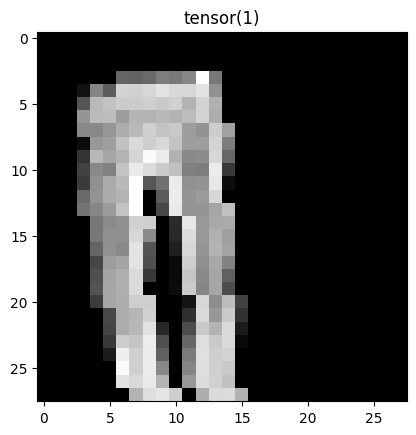

In [ ]:
I, l = next(iter(augmented_dataloader))
plt.imshow(I[0][0], cmap="gray")
plt.title(l[0])
plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
d, l = next(iter(train_dataloader))
d.shape, l.shape, len(d)

(torch.Size([32, 1, 28, 28]), torch.Size([32]), 32)

In [ ]:
def training_cycle(Model, train_dataloader, test_dataloader, epoch):
  train_loss = []
  test_losses = []
  accu = []
  optimizer = torch.optim.Adam(Model.parameters(), lr=0.01)
  loss_fn = torch.nn.CrossEntropyLoss()

  for i in tqdm(range(epoch)):
    print(f"Epoch #{i+1}")
    train_loss_total = 0
    Model.train()
    for batch, (X,y) in enumerate(train_dataloader):
      X, y = X.to(device), y.to(device)
      y_preds = Model(X)
      loss = loss_fn(y_preds, y)
      train_loss_total += loss.item()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if batch % 400 ==0:
        print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss_total = train_loss_total/len(train_dataloader)
    test_loss, test_acc = 0, 0
    Model.eval()
    with torch.inference_mode():
      for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        test_preds = Model(X)
        test_loss += loss_fn(test_preds, y).item()
        test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))
    test_loss = test_loss/len(test_dataloader)
    test_acc = test_acc/len(test_dataloader)
    train_loss.append(train_loss_total)
    test_losses.append(test_loss)
    accu.append(test_acc)
    print(f"Epoch #{i+1} | Train Loss: {train_loss_total:.4f}| Train Loss: {test_loss:.4f}| Accuracy : {test_acc:.4f}%")
    print("===================================")
  return train_loss, test_losses, accu

In [ ]:
base_model = CNNV1(input_shape=1, hidden_units=10, output_shape=10).to(device)
train_loss, test_losses, accu = training_cycle(base_model, train_dataloader, test_dataloader, 3) # Base Model W/o Dropout, BatchNorm or Data Augementation

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch #1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #1 | Train Loss: 0.5569| Train Loss: 0.4123| Accuracy : 85.0739%
Epoch #2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #2 | Train Loss: 0.3550| Train Loss: 0.3492| Accuracy : 87.1406%
Epoch #3
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #3 | Train Loss: 0.3162| Train Loss: 0.3227| Accuracy : 88.6182%


In [ ]:
modelv2 = CNNV2(input_shape=1, hidden_units=10, output_shape=10).to(device)
train_loss2, test_losses2, accu2 = training_cycle(modelv2, train_dataloader, test_dataloader, 3) # Model W/o BatchNorm or Data Augementation

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch #1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #1 | Train Loss: 0.5709| Train Loss: 0.4079| Accuracy : 86.5415%
Epoch #2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #2 | Train Loss: 0.3947| Train Loss: 0.3900| Accuracy : 85.7328%
Epoch #3
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #3 | Train Loss: 0.3668| Train Loss: 0.3406| Accuracy : 88.1689%


In [ ]:
modelv3 = CNNV3(input_shape=1, hidden_units=10, output_shape=10).to(device)
train_loss3, test_losses3, accu3 = training_cycle(modelv3, train_dataloader, test_dataloader, 3) # Model W/o Data Augementation

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch #1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #1 | Train Loss: 0.4739| Train Loss: 0.3933| Accuracy : 85.4633%
Epoch #2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #2 | Train Loss: 0.3357| Train Loss: 0.3009| Accuracy : 89.0675%
Epoch #3
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #3 | Train Loss: 0.3039| Train Loss: 0.3039| Accuracy : 89.1873%


In [ ]:
modelv4 = CNNV3(input_shape=1, hidden_units=10, output_shape=10).to(device)
train_loss4, test_losses4, accu4 = training_cycle(modelv4, augmented_dataloader, test_dataloader, 3) # Model with Dropout, Batch Norm and Data Augementation

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch #1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #1 | Train Loss: 1.0883| Train Loss: 0.6550| Accuracy : 74.6905%
Epoch #2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #2 | Train Loss: 0.7398| Train Loss: 0.6577| Accuracy : 74.7304%
Epoch #3
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch #3 | Train Loss: 0.6968| Train Loss: 0.5826| Accuracy : 78.7440%


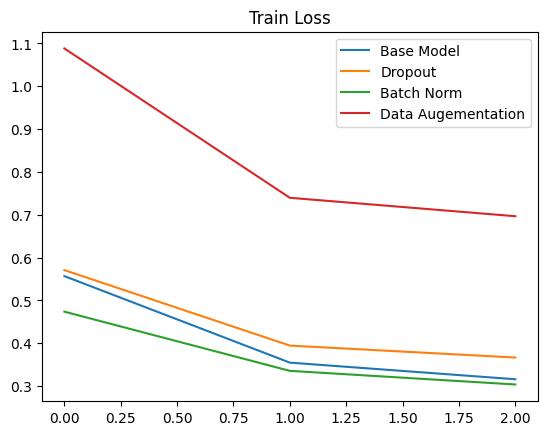

In [ ]:
plt.plot(train_loss, label="Base Model")
plt.plot(train_loss2, label="Dropout")
plt.plot(train_loss3, label="Batch Norm")
plt.plot(train_loss4, label="Data Augementation")
plt.legend()
plt.title("Train Loss")
plt.show()

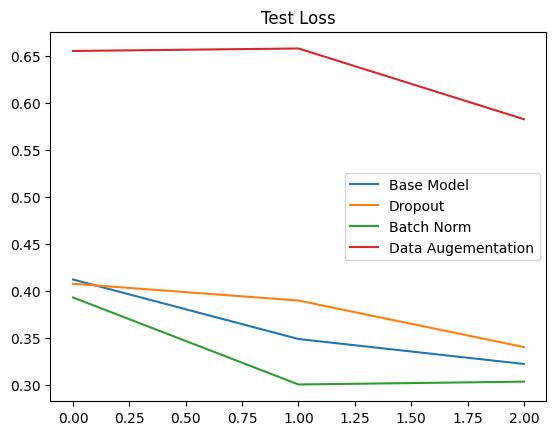

In [ ]:
plt.plot(test_losses, label="Base Model")
plt.plot(test_losses2, label="Dropout")
plt.plot(test_losses3, label="Batch Norm")
plt.plot(test_losses4, label="Data Augementation")
plt.legend()
plt.title("Test Loss")
plt.show()

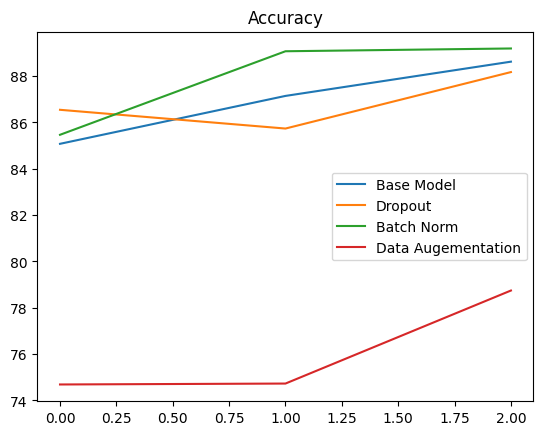

In [ ]:
plt.plot(accu, label="Base Model")
plt.plot(accu2, label="Dropout")
plt.plot(accu3, label="Batch Norm")
plt.plot(accu4, label="Data Augementation")
plt.legend()
plt.title("Accuracy")
plt.show()

Augemented Model Failed to prove usefulness. Best model is the Model with Batch Norm and Dropout in this case. However, training Data Augemented Model for longer will most likely result in it improving.